In [1]:
%load_ext autoreload
%autoreload 2
# !hostname
# !pwd
import os, sys
# print(sys.executable)
# os.environ['CUDA_VISIBLE_DEVICES'] = "7"
os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = "false"
# sys.path.append(os.path.abspath(".."))

In [2]:
import os, sys, glob, pickle, copy, time
from functools import partial

import numpy as np
import pandas as pd
# import xarray as xr
import matplotlib.pyplot as plt
# plt.rcParams['figure.figsize'] = (15, 5)
import seaborn as sns
sns.set_theme()

from tqdm.auto import tqdm
from einops import rearrange, reduce, repeat
# from einop import einop

import jax
import jax.numpy as jnp
from jax.random import split

import flax
import flax.linen as nn
from flax.training.train_state import TrainState

import optax

import experiment_utils
from main import *
import plotstyle
plotstyle.set_plot_style()

In [3]:
from models.mae import GPTConfig, MAEConfig, MAE

In [4]:
import train_mae
argd = train_mae.Args()

argd.n_iters = 30000
argd.log_every = 10000

args_all = []
seeds_all = range(5)
beta2_all = [0.95, 0.999]
batch_size_all = [16, 32, 64, 128, 256, 512]
for seed in seeds_all:
    for beta2 in beta2_all:
        for batch_size in batch_size_all:
            args = copy.deepcopy(argd)
            args.seed = seed
            args.opt.beta2 = beta2
            args.opt.batch_size = batch_size

            args.save_dir = f"/home/akarsh_sakana_ai/alife-repr-data/mae_run_0/seed={seed}_beta2={beta2}_batch_size={batch_size}"
            args_all.append(args)
experiment_utils.create_commands(args_all, prefix="python train_mae.py", out_file="science_scripts/train_mae.sh");

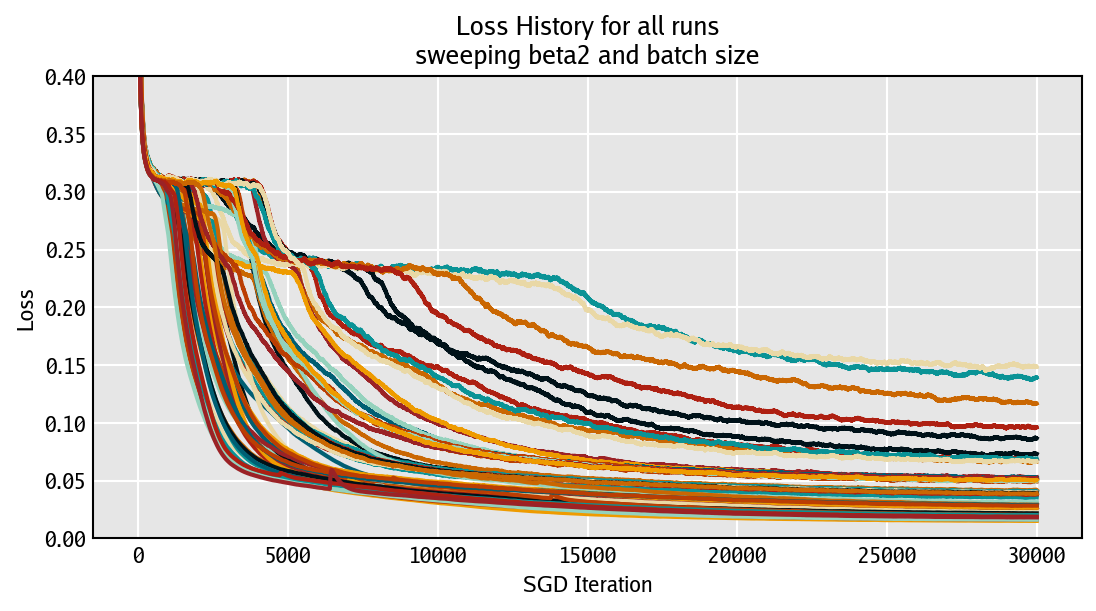

In [5]:
for args in args_all:
    loss_history = util.load_pkl(args.save_dir, "loss_history")
    loss_history = pd.DataFrame(loss_history).ewm(span=500).mean()
    plt.plot(loss_history)
plt.ylabel("Loss")
plt.xlabel("SGD Iteration")
plt.title("Loss History for all runs\nsweeping beta2 and batch size")
plt.ylim(0, .4)
plt.show()

In [6]:
df = []

for args in args_all:
    loss_history = util.load_pkl(args.save_dir, "loss_history")
    loss_history = np.array(pd.DataFrame(loss_history).ewm(span=500).mean())[:, 0]
    loss_final = util.load_pkl(args.save_dir, "final_loss")
    loss_history_mean = loss_history.mean()
    df.append(dict(seed=args.seed, beta2=args.opt.beta2, batch_size=args.opt.batch_size, loss_final=loss_final, loss_history_mean=loss_history_mean))

df = pd.DataFrame(df)

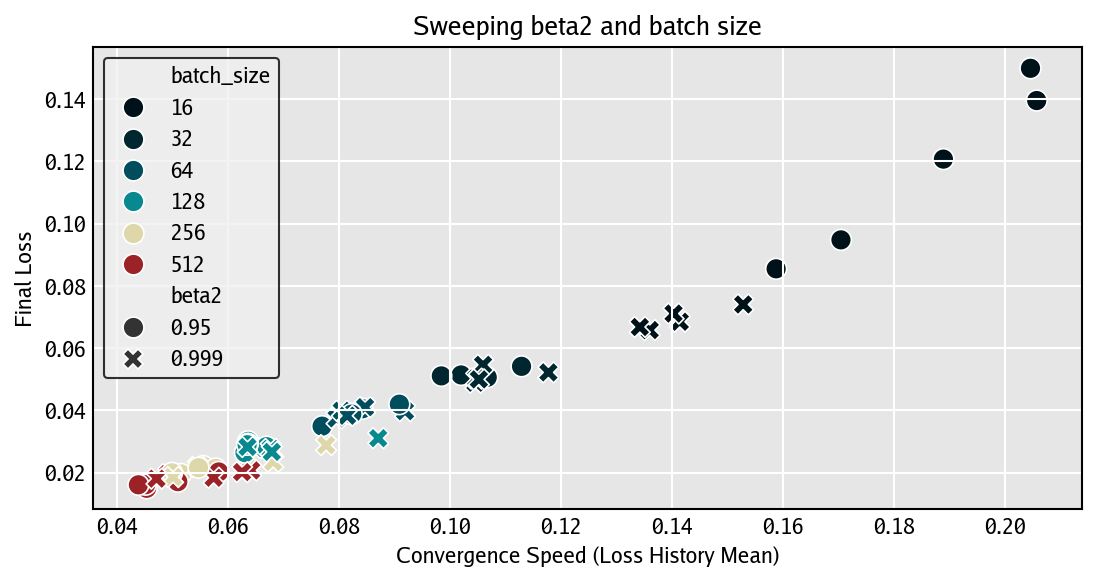

In [9]:
sns.scatterplot(data=df, x="loss_history_mean", y="loss_final", hue="batch_size", style="beta2", s=100, palette="ak0")
# plt.xscale('log')
# plt.yscale('log')
plt.xlabel("Convergence Speed (Loss History Mean)")
plt.ylabel("Final Loss")
plt.title("Sweeping beta2 and batch size")
plt.show()

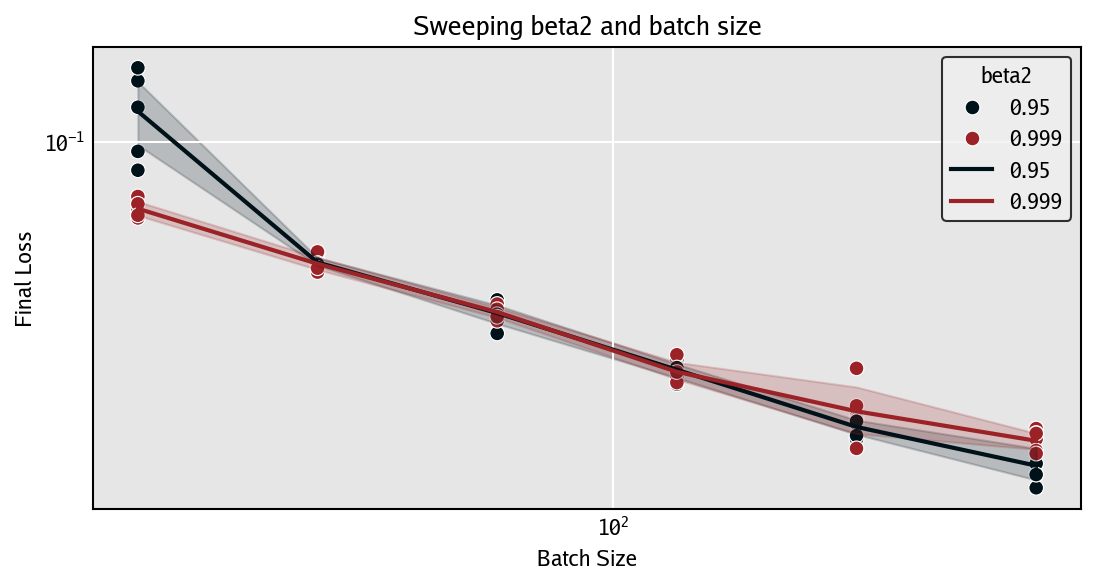

In [10]:
sns.scatterplot(data=df, x="batch_size", y="loss_final", hue="beta2", s=50, palette="ak0")
sns.lineplot(data=df, x="batch_size", y="loss_final", hue="beta2", palette="ak0")
plt.xscale('log')
plt.yscale('log')
# plt.ylim(0, 0.05)
plt.xlabel("Batch Size")
plt.ylabel("Final Loss")
plt.title("Sweeping beta2 and batch size")
plt.show()

In [185]:
args = args_all[-1]
main = train_mae.Main(args)
main.init()
params = util.load_pkl(args.save_dir, "params")

ctx_len: 256
patch_dim: 16

                                  MAE Summary                                   
┏━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━┓
┃ path          ┃ module        ┃ inputs        ┃ outputs       ┃ params       ┃
┡━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━┩
│               │ MAE           │ - uint32[2]   │ features:     │              │
│               │               │ -             │ float32[12,2… │              │
│               │               │ int32[4,32,3… │ idx_keep:     │              │
│               │               │               │ int32[230]    │              │
│               │               │               │ idx_mask:     │              │
│               │               │               │ int32[26]     │              │
│               │               │               │ input_mask:   │              │
│               │               │               │ int32[4,32,3… │              │


In [186]:
rng = jax.random.PRNGKey(0)
batch = main.data_gen.generate_batch(rng)

In [187]:
loss, outputs = main.loss_fn(params, batch)

ctx_len: 256
patch_dim: 16


In [188]:
jax.tree.map(lambda x: x.shape, outputs)

{'features': (512, 12, 230, 256),
 'idx_keep': (512, 230),
 'idx_mask': (512, 26),
 'input_mask': (512, 4, 32, 32),
 'logits': (512, 4, 32, 32),
 'loss': (512,),
 'loss_ce': (512, 4, 32, 32),
 'x_enc': (512, 230, 256),
 'x_in': (512, 4, 32, 32)}

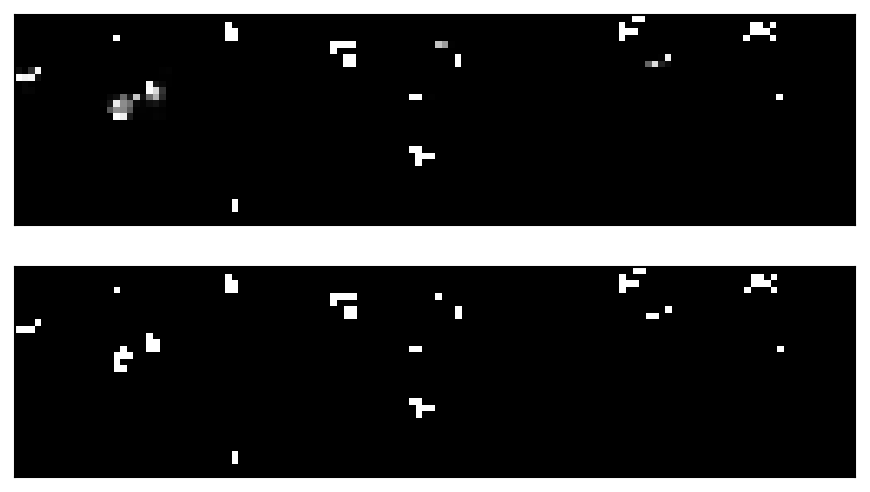

In [189]:
input_mask = outputs['input_mask']
probs = jax.nn.sigmoid(outputs['logits'])
probs = probs * input_mask
x_in = outputs['x_in']
x_in = x_in * input_mask
i = 16
plt.subplot(211)
plt.imshow(rearrange(probs[i], "T H W -> H (T W)"), cmap='gray', vmin=0, vmax=1)
plt.xticks([]); plt.yticks([])
plt.subplot(212)
plt.imshow(rearrange(x_in[i], "T H W -> H (T W)"), cmap='gray', vmin=0, vmax=1)
plt.xticks([]); plt.yticks([])
plt.show()

In [190]:
args = copy.deepcopy(args_all[0])
args.opt.decay_lr = False

In [191]:
# lr_final = args.opt.learning_rate/10 if args.opt.decay_lr else args.opt.learning_rate
lr_final = args.opt.learning_rate/10 if args.opt.decay_lr else args.opt.learning_rate
lr_schedule = optax.warmup_cosine_decay_schedule(init_value=0., peak_value=args.opt.learning_rate,
                                                    warmup_steps=args.n_iters//100,
                                                    decay_steps=args.n_iters-args.n_iters//100,
                                                    end_value=lr_final, exponent=1.)

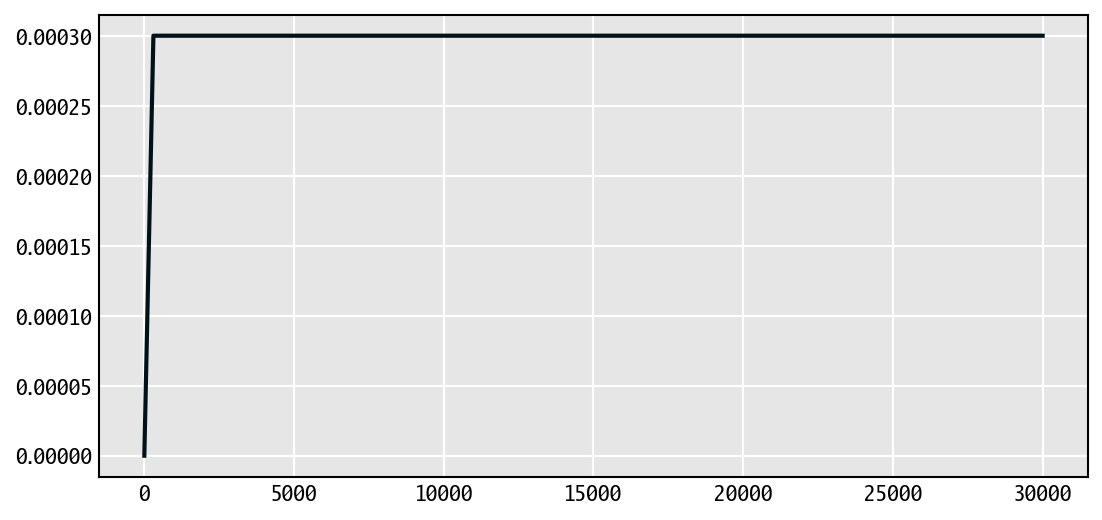

In [192]:
plt.plot(lr_schedule(jnp.arange(args.n_iters)))
plt.show()

In [11]:
import train_mae
argd = train_mae.Args()

argd.n_iters = 30000
argd.log_every = 10000

argd.opt.batch_size = 64
argd.opt.beta2 = 0.999

args_all = []
seeds_all = range(3)
lrs_all = [1e-5, 3e-5, 1e-4, 3e-4, 1e-3, 3e-3]
decay_lr_all = [True, False]

for seed in seeds_all:
    for lr in lrs_all:
        for decay_lr in decay_lr_all:
            args = copy.deepcopy(argd)
            args.seed = seed
            args.opt.learning_rate = lr
            args.opt.decay_lr = decay_lr

            args.save_dir = f"/home/akarsh_sakana_ai/alife-repr-data/mae_run_0/seed={seed}_lr={lr}_decay_lr={decay_lr}"
            args_all.append(args)
experiment_utils.create_commands(args_all, prefix="python train_mae.py", out_file="science_scripts/train_mae.sh");

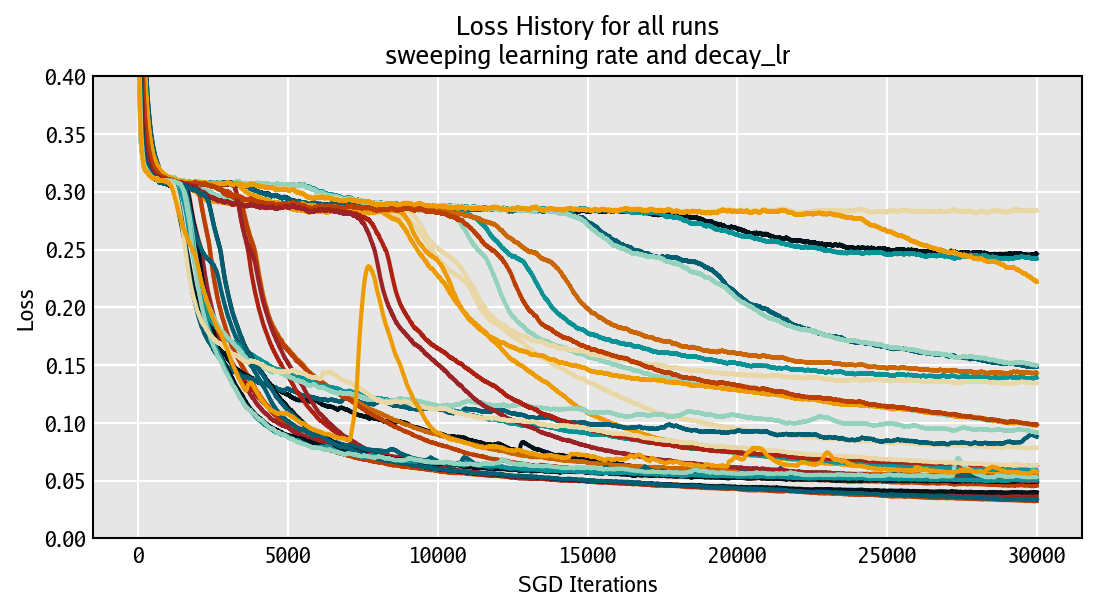

In [12]:
for args in args_all:
    loss_history = util.load_pkl(args.save_dir, "loss_history")
    loss_history = pd.DataFrame(loss_history).ewm(span=500).mean()
    plt.plot(loss_history)
plt.ylabel("Loss")
plt.xlabel("SGD Iterations")
plt.title("Loss History for all runs\nsweeping learning rate and decay_lr")
plt.ylim(0, .4)
plt.show()

In [13]:
df = []

for args in args_all:
    loss_history = util.load_pkl(args.save_dir, "loss_history")
    loss_history = np.array(pd.DataFrame(loss_history).ewm(span=500).mean())[:, 0]
    loss_final = util.load_pkl(args.save_dir, "final_loss")
    loss_history_mean = loss_history.mean()
    df.append(dict(seed=args.seed, lr=args.opt.learning_rate, decay_lr=args.opt.decay_lr, loss_final=loss_final, loss_history_mean=loss_history_mean))

df = pd.DataFrame(df)

In [14]:
df

,seed,lr,decay_lr,loss_final,loss_history_mean
0,0,0.00001,True,0.245424,0.280777
1,0,0.00001,False,0.147750,0.247265
2,0,0.00003,True,0.138463,0.214456
3,0,0.00003,False,0.097917,0.196153
4,0,0.00010,True,0.078019,0.174145
5,0,0.00010,False,0.054435,0.158832
6,0,0.00030,True,0.038875,0.080525
7,0,0.00030,False,0.031565,0.078783
8,0,0.00100,True,0.048724,0.084962
9,0,0.00100,False,0.048402,0.084306


Text(0.5, 1.0, 'Sweeping learning rate and decay_lr')

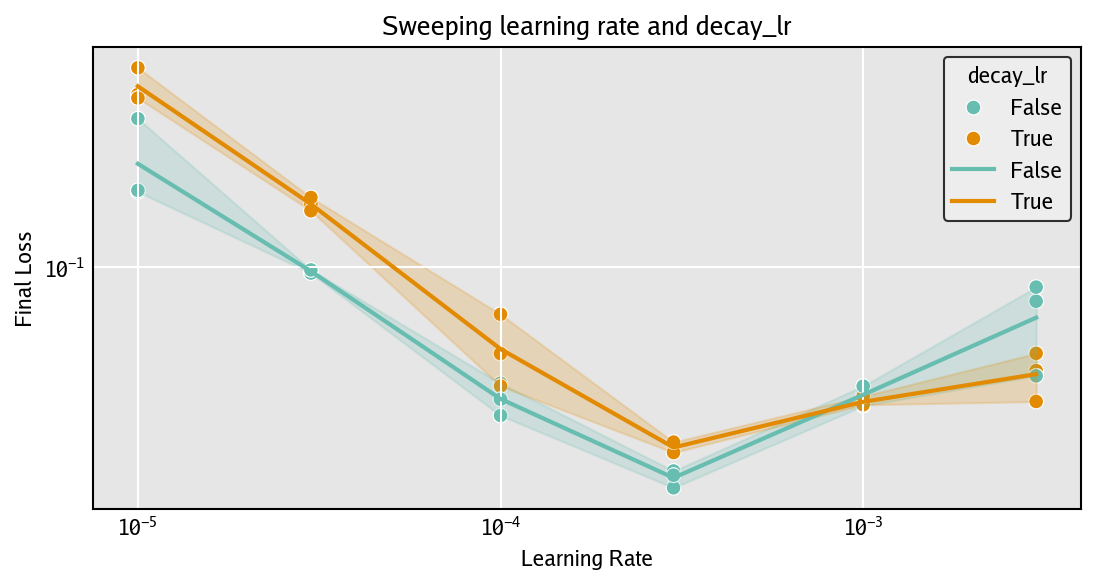

In [16]:
sns.scatterplot(data=df, x="lr", y="loss_final", hue="decay_lr", palette="ak0", s=50)
sns.lineplot(data=df, x="lr", y="loss_final", hue="decay_lr", palette="ak0")
plt.xscale('log')
plt.yscale('log')
plt.xlabel("Learning Rate")
plt.ylabel("Final Loss")
plt.title("Sweeping learning rate and decay_lr")

In [4]:
import train_mae
argd = train_mae.Args()

argd.n_iters = 100000
argd.log_every = 10000

args_all = []
seeds_all = range(3)
argd.opt.beta2 = 0.999
argd.opt.batch_size = 256
argd.opt.learning_rate = 3e-4
argd.opt.decay_lr = True

mask_ratio_all = [0.01, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 0.9]
for seed in seeds_all:
    for mask_ratio in mask_ratio_all:
        args = copy.deepcopy(argd)
        args.seed = seed
        args.model.mask_ratio = mask_ratio
        args.save_dir = f"/home/akarsh_sakana_ai/alife-repr-data/mae_run_0/seed={seed}_mask_ratio={mask_ratio}"
        args_all.append(args)
experiment_utils.create_commands(args_all, prefix="python train_mae.py", out_file="science_scripts/train_mae.sh");

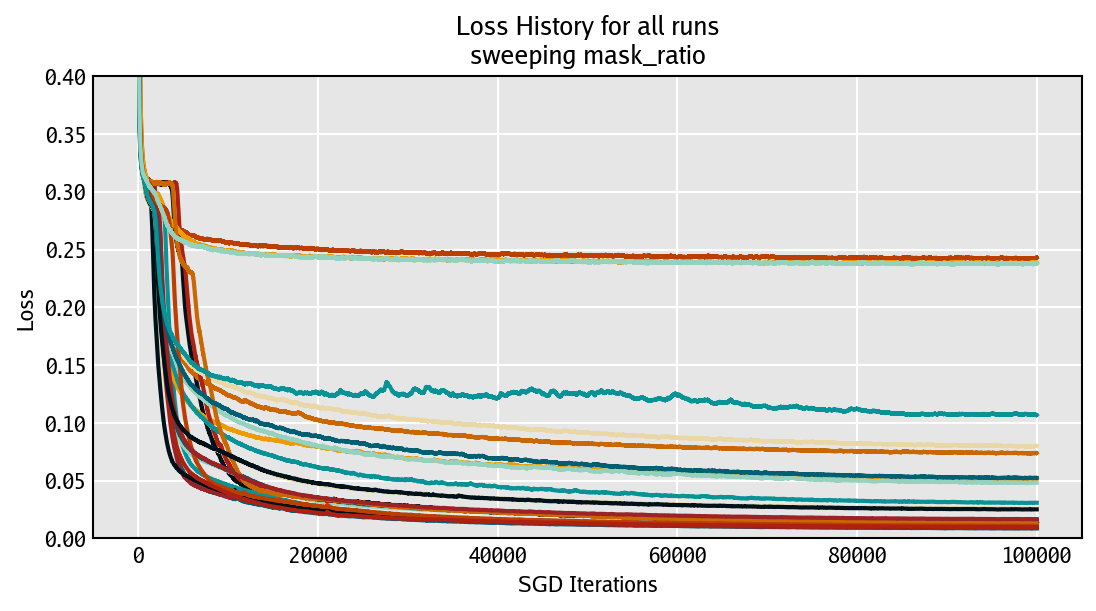

In [5]:
for args in args_all:
    loss_history = util.load_pkl(args.save_dir, "loss_history")
    loss_history = pd.DataFrame(loss_history).ewm(span=500).mean()
    plt.plot(loss_history)
plt.ylabel("Loss")
plt.xlabel("SGD Iterations")
plt.title("Loss History for all runs\nsweeping mask_ratio")
plt.ylim(0, .4)
plt.show()

In [6]:
df = []

for args in args_all:
    loss_history = util.load_pkl(args.save_dir, "loss_history")
    loss_history = np.array(pd.DataFrame(loss_history).ewm(span=500).mean())[:, 0]
    loss_final = util.load_pkl(args.save_dir, "final_loss")
    loss_history_mean = loss_history.mean()
    df.append(dict(seed=args.seed, mask_ratio=args.model.mask_ratio, loss_final=loss_final, loss_history_mean=loss_history_mean))

df = pd.DataFrame(df)

In [7]:
df

,seed,mask_ratio,loss_final,loss_history_mean
0,0,0.01,0.013550,0.040505
1,0,0.05,0.008784,0.025052
2,0,0.10,0.010944,0.030090
3,0,0.20,0.015607,0.034298
4,0,0.30,0.025934,0.045137
5,0,0.40,0.051645,0.072576
6,0,0.50,0.073844,0.095274
7,0,0.90,0.242331,0.249104
8,1,0.01,0.013671,0.041543
9,1,0.05,0.008921,0.025256


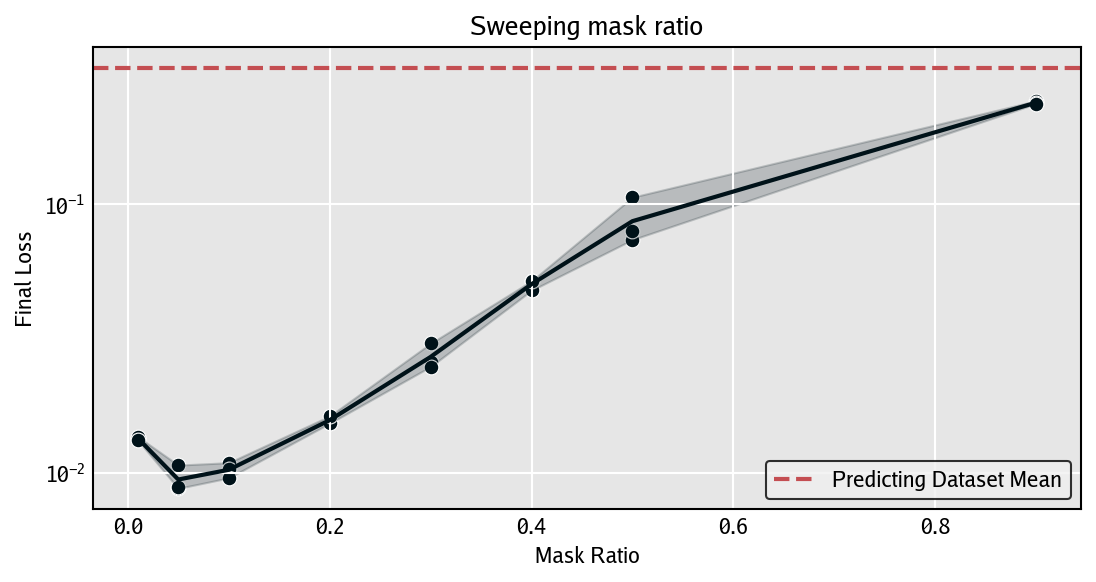

In [8]:
sns.scatterplot(data=df, x="mask_ratio", y="loss_final", s=50)
sns.lineplot(data=df, x="mask_ratio", y="loss_final")
plt.axhline(y=0.32, c='r', ls='--', label="Predicting Dataset Mean")
plt.yscale('log')
# plt.ylim(0, 0.4)
plt.xlabel("Mask Ratio")
plt.ylabel("Final Loss")
plt.title("Sweeping mask ratio")
plt.legend()
plt.show()

In [6]:
rng = jax.random.PRNGKey(0)
args = args_all[0]
main = train_mae.Main(args)
batch = main.data_gen.generate_batch(rng, batch_size=8192)
substrate = main.data_gen.substrate
gol_params = main.data_gen.args.gol_params
# forward_fn = jax.jit(jax.vmap(partial(main.model.apply, method=main.model.embed_tensor), in_axes=(None, 0)))
# forward_fn = jax.jit(partial(main.model.apply, method=main.model.embed_tensor))
@jax.jit
def forward_fn(params, state):
    features = main.model.apply(params, state, method=main.model.embed_tensor)['features']
    return features.mean(axis=-2)

In [10]:
from foundation_models.clip import CLIP
clip = CLIP()
def forward_fn_clip(state):
    img = jax.vmap(partial(substrate.render_state, params=gol_params, img_size=224))(state)
    z_clip = jax.vmap(clip.embed_img)(img)
    return z_clip
forward_fn_clip = jax.jit(forward_fn_clip)

In [23]:
z_clip = jax.lax.map(forward_fn_clip, batch['state'], batch_size=512)
z_clip = rearrange(z_clip, "B T D -> B (T D)")
z_clip_train, z_clip_test = z_clip[:int(len(z_clip)*.8)], z_clip[int(len(z_clip)*.8):]
print(z_clip_train.shape, z_clip_test.shape)

(6553, 2048) (1639, 2048)


In [48]:
from sklearn.linear_model import LinearRegression

df = []
for args in tqdm(args_all):
    main = train_mae.Main(args)
    params = util.load_pkl(args.save_dir, "params")
    loss_final = util.load_pkl(args.save_dir, "final_loss")

    forward_fn_params = partial(forward_fn, params)
    features = jax.lax.map(forward_fn_params, batch['state'], batch_size=512)
    features = rearrange(features, "B L D -> B (L D)")
    features_train, features_test = features[:int(len(features)*.8)], features[int(len(features)*.8):]
    # print(features_train.shape, features_test.shape)
    reg = LinearRegression().fit(features_train, z_clip_train)
    r2_train = reg.score(features_train, z_clip_train)
    r2_test = reg.score(features_test, z_clip_test)
    # print(f"R2 train: {r2_train}, R2 test: {r2_test}")

    dfi = dict(seed=args.seed, mask_ratio=args.model.mask_ratio, loss_final=loss_final, r2_train=r2_train, r2_test=r2_test)
    df.append(dfi)
df = pd.DataFrame(df)

  0%|          | 0/24 [00:00<?, ?it/s]

100%|██████████| 24/24 [04:42<00:00, 11.78s/it]


In [ ]:
main = train_mae.Main(args)
main.init()
# params = util.load_pkl(args.save_dir, "params")
params = main.train_state.params

forward_fn_params = partial(forward_fn, params)
features = jax.lax.map(forward_fn_params, batch['state'], batch_size=512)
features = rearrange(features, "B L D -> B (L D)")
features_train, features_test = features[:int(len(features)*.8)], features[int(len(features)*.8):]
print(features_train.shape, features_test.shape)
reg = LinearRegression().fit(features_train, z_clip_train)
r2_train_rand = reg.score(features_train, z_clip_train)
r2_test_rand = reg.score(features_test, z_clip_test)
print(f"R2 train: {r2_train_rand}, R2 test: {r2_test_rand}")

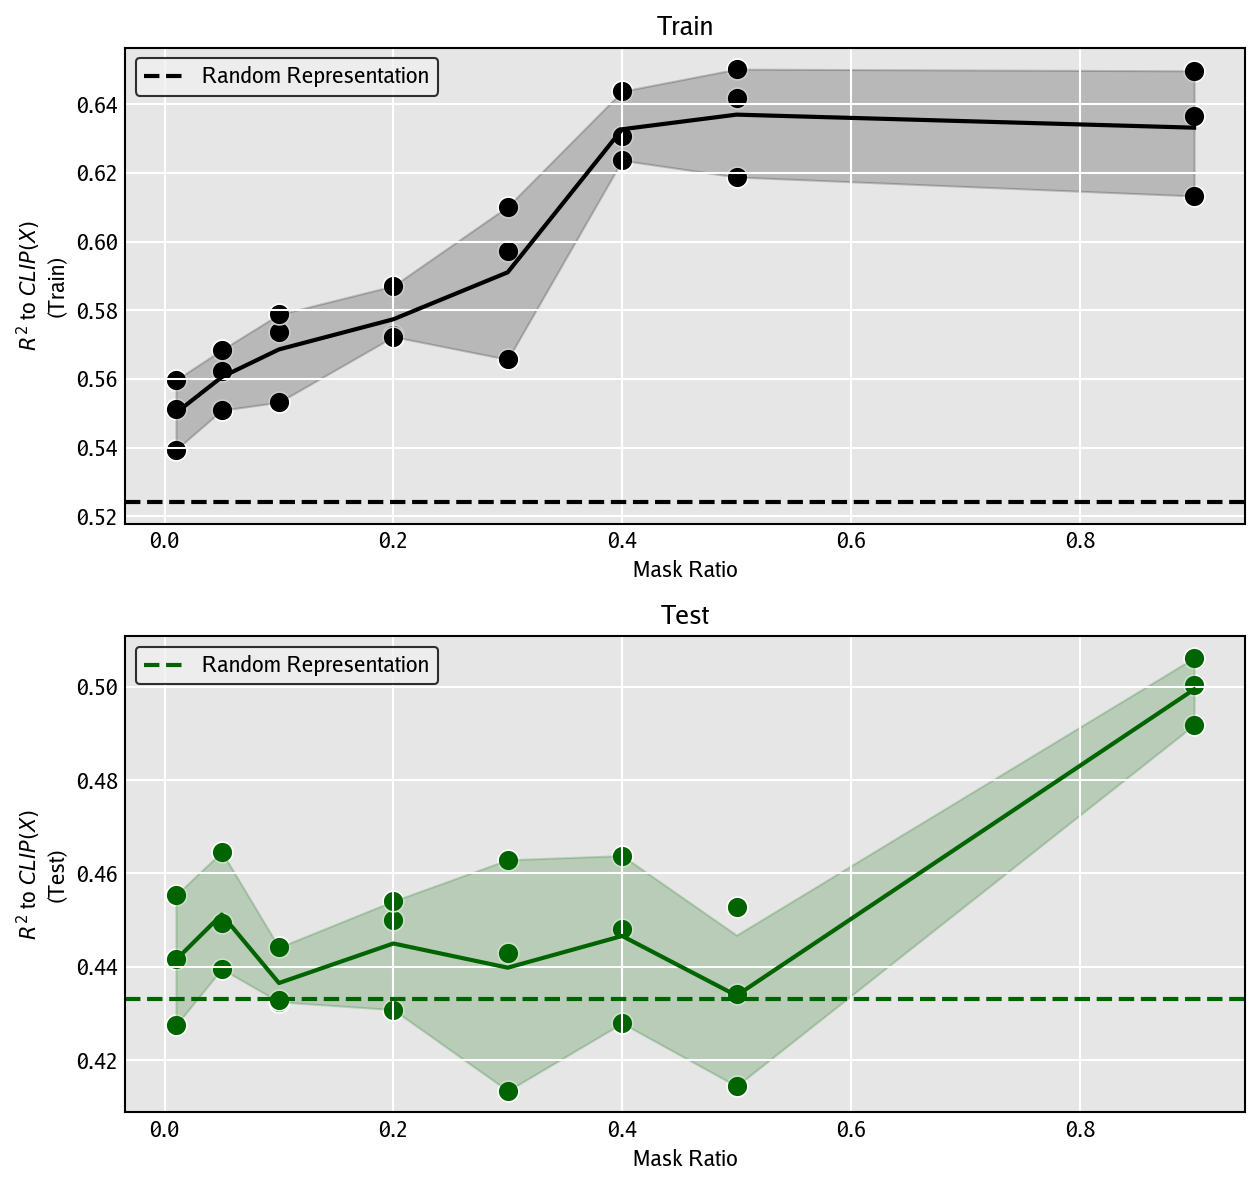

In [76]:
plt.figure(figsize=(8.5, 8))
plt.subplot(211)
sns.scatterplot(data=df, x="mask_ratio", y="r2_train", c='black', s=100)
sns.lineplot(data=df, x="mask_ratio", y="r2_train", c='black')
plt.axhline(y=r2_train_rand, c='black', ls='--', label='Random Representation')
plt.legend()
plt.xlabel("Mask Ratio"); plt.ylabel("$R^2$ to $CLIP(X)$\n(Train)"); plt.title("Train")

plt.subplot(212)
sns.scatterplot(data=df, x="mask_ratio", y="r2_test", c='darkgreen', s=100)
sns.lineplot(data=df, x="mask_ratio", y="r2_test", c='darkgreen')
plt.axhline(y=r2_test_rand, c='darkgreen', ls='--', label='Random Representation')
plt.legend()
plt.xlabel("Mask Ratio"); plt.ylabel("$R^2$ to $CLIP(X)$\n(Test)"); plt.title("Test")
plt.tight_layout()
plt.show()

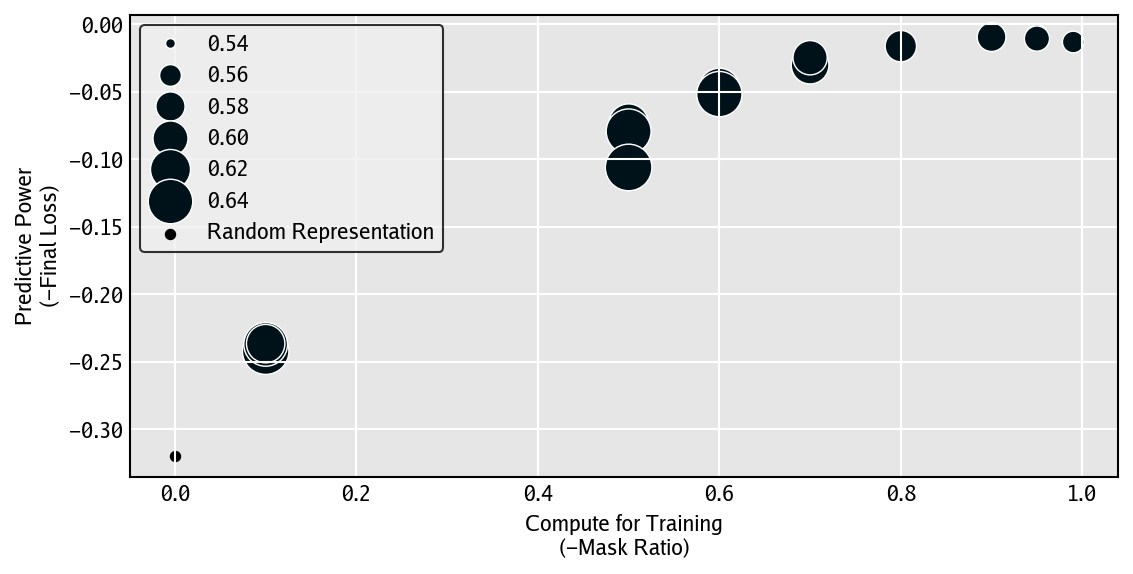

In [85]:
sns.scatterplot(data=df, x=(1-df['mask_ratio']), y=-df['loss_final'], size='r2_train', sizes=(20, 500))

plt.scatter([0.], [-.32], s=20, c='black', label='Random Representation')
plt.xlabel("Compute for Training\n(-Mask Ratio)"); plt.ylabel("Predictive Power\n(-Final Loss)")
plt.legend()

    # sns.scatterplot(data=dfa, x='total_flops', y='rollout_accuracy', hue='dt', style='layers', palette='ak0', size='score_x0', sizes=(20, 200))


In [25]:
import train_mae
argd = train_mae.Args()

argd.n_iters = 100000
argd.log_every = 10000

args_all = []
seeds_all = range(3)
argd.opt.beta2 = 0.999
argd.opt.batch_size = 512
argd.opt.grad_accum_steps = 2
argd.opt.learning_rate = 3e-4
argd.opt.decay_lr = True
argd.model.mask_ratio = 0.25

tensor_shape_all = [(4, 32, 32), (8, 64, 64), (16, 128, 128)]
patch_shape_all = [(1, 4, 4), (2, 8, 8), (4, 16, 16)]

for seed in seeds_all:
    for tensor_shape, patch_shape in zip(tensor_shape_all, patch_shape_all):
        args = copy.deepcopy(argd)
        args.seed = seed
        args.model.tensor_shape = tensor_shape
        args.model.patch_shape = patch_shape
        args.data.grid_size = tensor_shape[-1]
        args.data.dt = tensor_shape[0]
        args.save_dir = f"/home/akarsh_sakana_ai/alife-repr-data/mae_run_0/seed={seed}_grid_size={args.data.grid_size}_dt={args.data.dt}"
        args_all.append(args)
experiment_utils.create_commands(args_all, prefix="python train_mae.py", out_file="science_scripts/train_mae.sh");

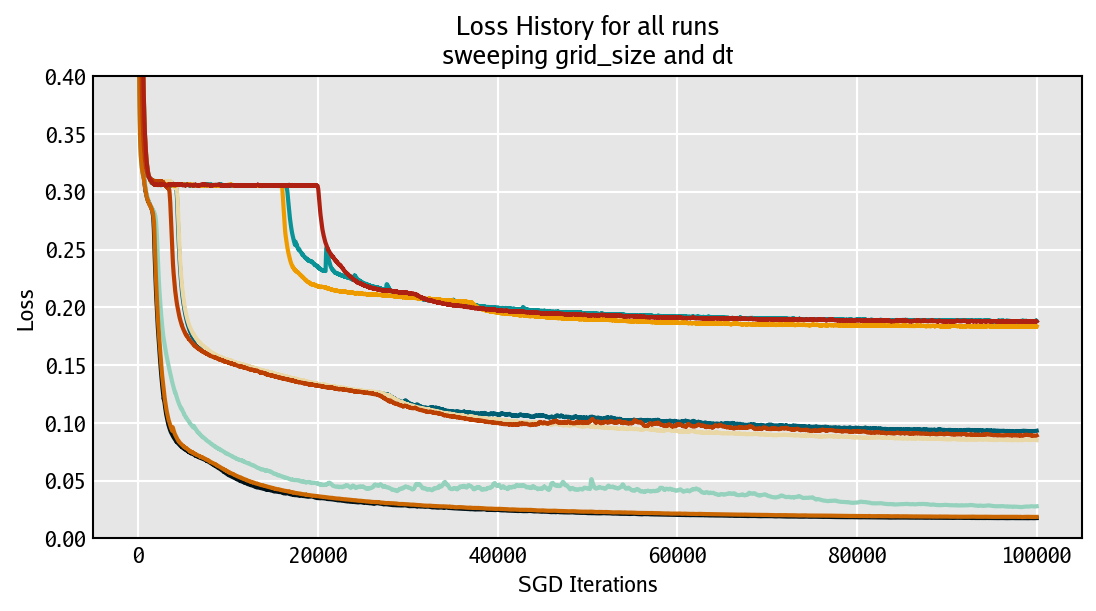

In [ ]:
for args in args_all:
    loss_history = util.load_pkl(args.save_dir, "loss_history")
    loss_history = pd.DataFrame(loss_history).ewm(span=500).mean()
    plt.plot(loss_history)
plt.ylabel("Loss")
plt.xlabel("SGD Iterations")
plt.title("Loss History for all runs\nsweeping grid_size and dt")
plt.ylim(0, .4)
plt.show()

In [27]:
df = []

for args in args_all:
    loss_history = util.load_pkl(args.save_dir, "loss_history")
    loss_history = np.array(pd.DataFrame(loss_history).ewm(span=500).mean())[:, 0]
    loss_final = util.load_pkl(args.save_dir, "final_loss")
    loss_history_mean = loss_history.mean()
    df.append(dict(seed=args.seed, grid_size=args.data.grid_size, dt=args.data.dt, loss_final=loss_final, loss_history_mean=loss_history_mean))

df = pd.DataFrame(df)

In [28]:
df

,seed,grid_size,dt,loss_final,loss_history_mean
0,0,32,4,0.017745,0.034755
1,0,64,8,0.093697,0.121671
2,0,128,16,0.188503,0.218772
3,1,32,4,0.027993,0.051836
4,1,64,8,0.084886,0.117249
5,1,128,16,0.183258,0.213799
6,2,32,4,0.018498,0.035950
7,2,64,8,0.089369,0.117678
8,2,128,16,0.187798,0.220674


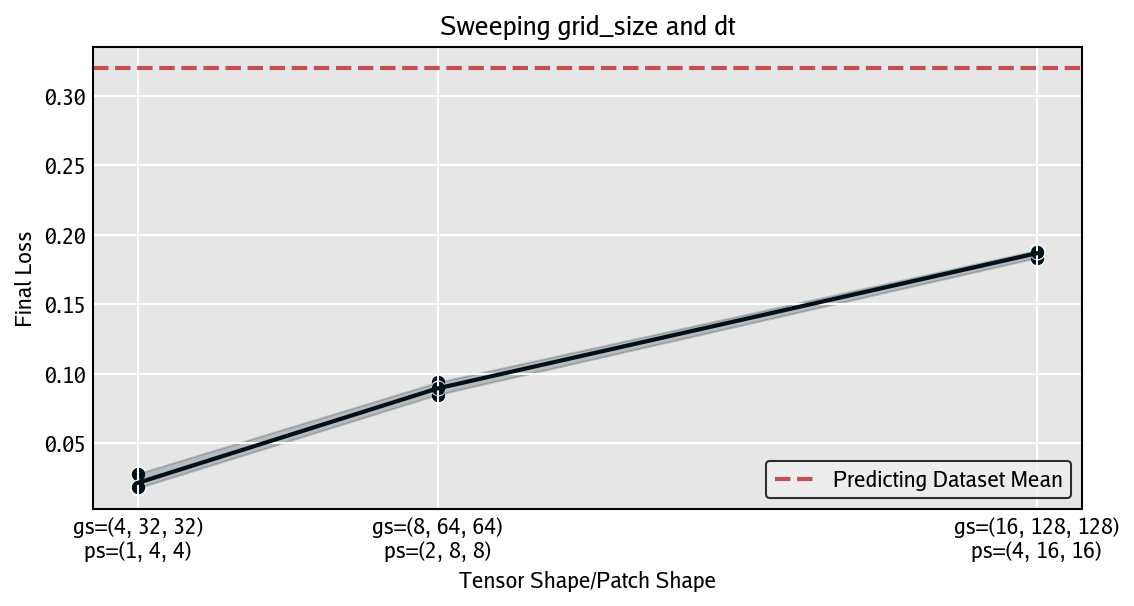

In [40]:
sns.scatterplot(data=df, x="grid_size", y="loss_final", s=50)
sns.lineplot(data=df, x="grid_size", y="loss_final")
# plt.xscale('log')
plt.xlabel("Tensor Shape/Patch Shape")
plt.ylabel("Final Loss")
plt.title("Sweeping grid_size and dt")
plt.axhline(y=0.32, c='r', ls='--', label="Predicting Dataset Mean")
plt.legend()
plt.xticks([32, 64, 128], ["gs=(4, 32, 32)\nps=(1, 4, 4)", "gs=(8, 64, 64)\nps=(2, 8, 8)", "gs=(16, 128, 128)\nps=(4, 16, 16)"])
plt.show()